In [11]:
import sys
import os
import pandas as pd

# 1. Add the path to the 'src' folder
# This goes up from .github/notebooks to the root, then into src
sys.path.append(os.path.abspath('../../src'))

# 2. Import your modular function
try:
    from text_utils import clean_text
    print("✅ Success! Modular script 'text_utils' is connected.")
except ModuleNotFoundError:
    print("❌ Still can't find it. Ensure 'text_utils.py' is saved in the 'src' folder.")

✅ Success! Modular script 'text_utils' is connected.


Transformation Steps:
Noise Removal: Using Regular Expressions (re), we remove special characters, numbers, and symbols. This ensures the model focuses purely on human language.

Case Normalization: All text is converted to lowercase to treat "Bank" and "bank" as the same token.

Tokenization: The text is broken down into individual words (tokens) using spaCy.

Stop-Word Removal: Common words that carry little emotional weight (like "the", "is", "at") are removed to reduce data "noise."

Lemmatization: Words are reduced to their dictionary root form (e.g., "working" and "works" both become "work"). This helps in grouping similar feedback themes later.

Note: By using a modular script, we ensure that this exact cleaning logic is applied consistently across all datasets (CBE, BOA, and Dashen), making our comparative analysis scientifically valid.

In [12]:
# 3. Load your data
# Since the CSV is in the same folder as the notebook, we just use the name
df = pd.read_csv('cbe_reviews_cleaned.csv')

df['processed_content'] = df['review_text'].apply(clean_text)

# Preview the first few rows
df[['review_text', 'processed_content']].head()

,review_text,processed_content
0,is good,good
1,wow,wow
2,Good application,good application
3,"Nice, but I can't get some recently transactio...",nice not recently transaction try history scro...
4,Very Secure but very poor interface and limite...,secure poor interface limited history service ...


In [13]:
from transformers import pipeline

sentiment_pipeline = pipeline(
    "sentiment-analysis", 
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

def get_sentiment(text):
    # BERT models have a limit of 512 characters, so we crop long reviews
    result = sentiment_pipeline(text[:512])[0]
    return result['label'], result['score']

# 6. Run sentiment analysis (this may take a minute)
df[['sentiment_label', 'sentiment_score']] = df['processed_content'].apply(
    lambda x: pd.Series(get_sentiment(x))
)

df.head()

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 296.03it/s]


,review_text,rating,review_date,bank,app_name,source,review_id,processed_content,sentiment_label,sentiment_score
0,is good,5,2026-05-13,CBE Bank,CBE BANK,Google Play,ff53332b-2e76-46d6-83d3-f93f968a4b18,good,POSITIVE,0.999816
1,wow,5,2026-05-13,CBE Bank,CBE BANK,Google Play,363a5616-ed3d-4274-85ee-77071067f81d,wow,POSITIVE,0.999592
2,Good application,2,2026-05-13,CBE Bank,CBE BANK,Google Play,56185597-d29b-4a60-a0fb-6783638230a7,good application,POSITIVE,0.999855
3,"Nice, but I can't get some recently transactio...",5,2026-05-13,CBE Bank,CBE BANK,Google Play,35efe702-40c9-4e46-ad67-7574ab9ef42d,nice not recently transaction try history scro...,POSITIVE,0.873846
4,Very Secure but very poor interface and limite...,1,2026-05-13,CBE Bank,CBE BANK,Google Play,b41cb49d-59d3-41b8-bbb2-b1952005951b,secure poor interface limited history service ...,NEGATIVE,0.999270


In [14]:
# Aggregate sentiment scores by bank
sentiment_by_bank = df.groupby('bank').agg({
    'sentiment_score': ['mean', 'std', 'count'],
    'sentiment_label': lambda x: (x == 'POSITIVE').sum() / len(x) * 100
}).round(3)
sentiment_by_bank.columns = ['avg_sentiment_score', 'std_sentiment_score', 'review_count', 'positive_percentage']
print("Sentiment by Bank:")
print(sentiment_by_bank)

# Aggregate sentiment scores by star rating
sentiment_by_rating = df.groupby('rating').agg({
    'sentiment_score': ['mean', 'std', 'count'],
    'sentiment_label': lambda x: (x == 'POSITIVE').sum() / len(x) * 100
}).round(3)
sentiment_by_rating.columns = ['avg_sentiment_score', 'std_sentiment_score', 'review_count', 'positive_percentage']
print("\nSentiment by Star Rating:")
print(sentiment_by_rating)

Sentiment by Bank:
          avg_sentiment_score  std_sentiment_score  review_count  \
bank                                                               
CBE Bank                0.969                0.084           450   

          positive_percentage  
bank                           
CBE Bank               78.444  

Sentiment by Star Rating:
        avg_sentiment_score  std_sentiment_score  review_count  \
rating                                                           
1                     0.987                0.043            65   
2                     0.989                0.027            10   
3                     0.946                0.112            31   
4                     0.920                0.132            37   
5                     0.974                0.079           307   

        positive_percentage  
rating                       
1                    27.692  
2                    60.000  
3                    61.290  
4                    67.568  
5         

# Thematic Analysis

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import numpy as np

# 1. Prepare text for topic modeling
texts = df['processed_content'].tolist()

# 2. Vectorize the text using TF-IDF
vectorizer = TfidfVectorizer(max_features=100, stop_words='english', min_df=2)
tfidf_matrix = vectorizer.fit_transform(texts)

# 3. Apply LDA for thematic analysis
lda_model = LatentDirichletAllocation(n_components=5, random_state=42, max_iter=20)
lda_model.fit(tfidf_matrix)

# 4. Display themes (top words per topic)
feature_names = vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(lda_model.components_):
    top_words_idx = topic.argsort()[-5:][::-1]
    top_words = [feature_names[i] for i in top_words_idx]
    print(f"Theme {topic_idx + 1}: {', '.join(top_words)}")

# 5. Assign dominant theme to each review
df['dominant_theme'] = lda_model.transform(tfidf_matrix).argmax(axis=1) + 1

Theme 1: work, update, app, need, bank
Theme 2: nice, ok, app, excellent, mobile
Theme 3: easy, use, application, fast, bad
Theme 4: app, cbe, like, transaction, time
Theme 5: good, app, wow, job, response


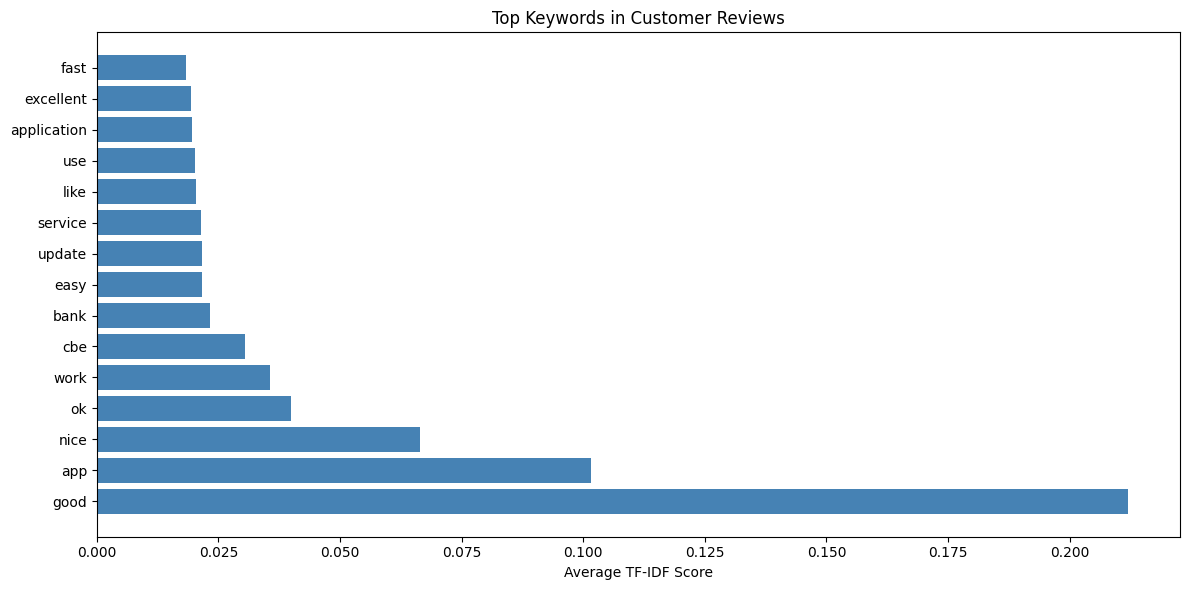

Top Bigrams (2-word phrases):
  - good app
  - nice app
  - mobile banking
  - easy use
  - good application
  - good service
  - good job
  - update app
  - transfer telebirr
  - mobile app


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

import matplotlib.pyplot as plt

# 1. Extract top keywords using TF-IDF
top_n = 15
feature_importance = vectorizer.get_feature_names_out()[tfidf_matrix.mean(axis=0).A1.argsort()[-top_n:][::-1]]

# 2. Calculate TF-IDF scores for visualization
tfidf_scores = tfidf_matrix.mean(axis=0).A1
top_indices = tfidf_scores.argsort()[-top_n:][::-1]
top_keywords = feature_names[top_indices]
top_scores = tfidf_scores[top_indices]

# 3. Visualize top keywords
plt.figure(figsize=(12, 6))
plt.barh(top_keywords, top_scores, color='steelblue')
plt.xlabel('Average TF-IDF Score')
plt.title('Top Keywords in Customer Reviews')
plt.tight_layout()
plt.show()

# 4. Extract bigrams for n-gram analysis
bigram_vectorizer = TfidfVectorizer(ngram_range=(2, 2), max_features=10, stop_words='english', min_df=2)
bigram_matrix = bigram_vectorizer.fit_transform(texts)
bigrams = bigram_vectorizer.get_feature_names_out()
bigram_scores = bigram_matrix.mean(axis=0).A1.argsort()[-10:][::-1]

print("Top Bigrams (2-word phrases):")
for idx in bigram_scores:
    print(f"  - {bigrams[idx]}")

Theme Distribution:
review_theme
General                              229
Usability / UI                       150
Functionality / Features              27
Performance & Reliability             24
Security & Trust / Fees & Support     20
Name: count, dtype: int64


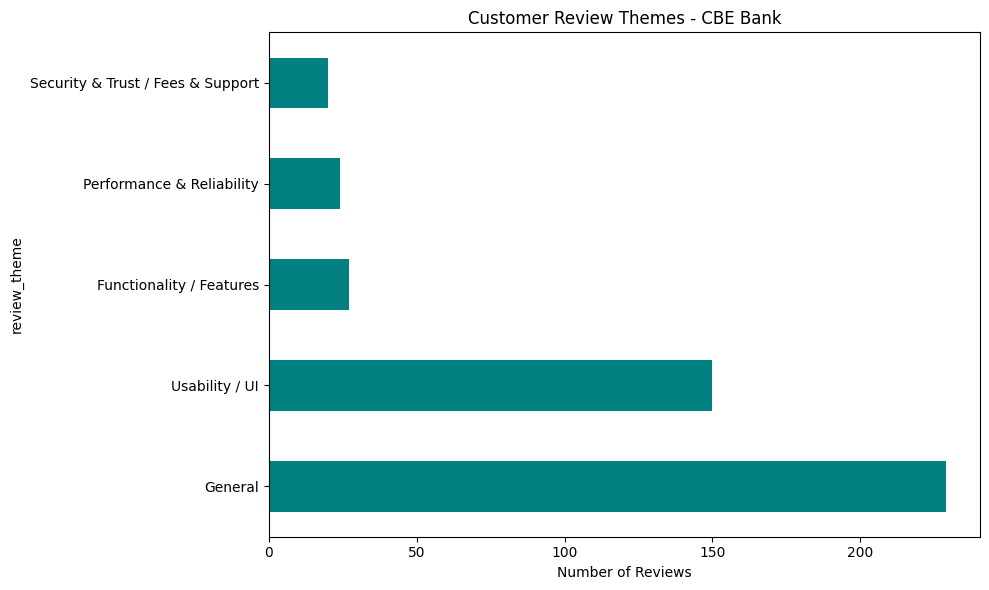


Sentiment Analysis by Theme:
                                   avg_sentiment  review_count  \
review_theme                                                     
Functionality / Features                   0.930            27   
General                                    0.965           229   
Performance & Reliability                  0.976            24   
Security & Trust / Fees & Support          0.985            20   
Usability / UI                             0.980           150   

                                   positive_percentage  
review_theme                                            
Functionality / Features                        51.852  
General                                         86.463  
Performance & Reliability                       54.167  
Security & Trust / Fees & Support               70.000  
Usability / UI                                  76.000  


In [18]:
import pandas as pd

import matplotlib.pyplot as plt

# 1. Define theme mappings based on keyword analysis and LDA results
themes = {
    'Usability / UI': ['easy', 'use', 'app', 'interface', 'update', 'application', 'user', 'page', 'nice'],
    'Functionality / Features': ['transfer', 'mobile', 'banking', 'wallet', 'payment', 'feature', 'transaction', 'history', 'beneficiary'],
    'Performance & Reliability': ['fast', 'crash', 'bug', 'error', 'work', 'properly', 'slow', 'sync'],
    'Security & Trust / Fees & Support': ['secure', 'confidence', 'fee', 'charge', 'customer', 'service', 'support', 'response']
}

# 2. Map dominant themes to each review based on keywords present
def assign_review_theme(processed_text):
    text_tokens = set(processed_text.split())
    theme_scores = {}
    
    for theme_name, keywords in themes.items():
        score = sum(1 for keyword in keywords if keyword in text_tokens)
        theme_scores[theme_name] = score
    
    # Return the theme with highest score, default to dominant_theme if tie
    if max(theme_scores.values()) > 0:
        return max(theme_scores, key=theme_scores.get)
    return 'General'

df['review_theme'] = df['processed_content'].apply(assign_review_theme)

# 3. Analyze theme distribution
theme_distribution = df['review_theme'].value_counts()
print("Theme Distribution:")
print(theme_distribution)

# 4. Visualize theme distribution
plt.figure(figsize=(10, 6))
theme_distribution.plot(kind='barh', color='teal')
plt.xlabel('Number of Reviews')
plt.title('Customer Review Themes - CBE Bank')
plt.tight_layout()
plt.show()

# 5. Analyze sentiment by theme
print("\nSentiment Analysis by Theme:")
sentiment_by_theme = df.groupby('review_theme').agg({
    'sentiment_score': ['mean', 'count'],
    'sentiment_label': lambda x: (x == 'POSITIVE').sum() / len(x) * 100
}).round(3)
sentiment_by_theme.columns = ['avg_sentiment', 'review_count', 'positive_percentage']
print(sentiment_by_theme)

CBE Bank — Overarching themes (4)

1. Usability / UI
    - Keywords: app, update, interface, ui, nice, ok, easy, use, user, version, page, navigation, visibility

2. Functionality / Features
    - Keywords: transfer, mobile banking, wallet, payment, standing order, beneficiary, feature, transaction, history, payment, airtime

3. Performance & Reliability
    - Keywords: fast, crash, bug, error, not work, slow, load, timeout, sync, properly

4. Security & Trust / Fees & Support
    - Keywords: secure, confidence, fee, charge, hidden fee, customer, service, support, response, scam, confirmation

Grouping logic
- Inputs: TF-IDF top keywords (top_keywords/top_scores), bigrams, LDA dominant terms and sample review tokens.
- Method: manually cluster lexically and semantically related terms into interpretable themes (merge synonyms and app-specific tokens like "mobile app" → Functionality).
- Rules: prioritize high-TF-IDF terms and frequent bigrams; create 3–5 themes that maximize coverage and are actionable for product/ops teams.
- Notes: Repeat/ambiguous tokens (e.g., "good", "nice") treated as sentiment markers, not theme drivers unless paired with functional terms.

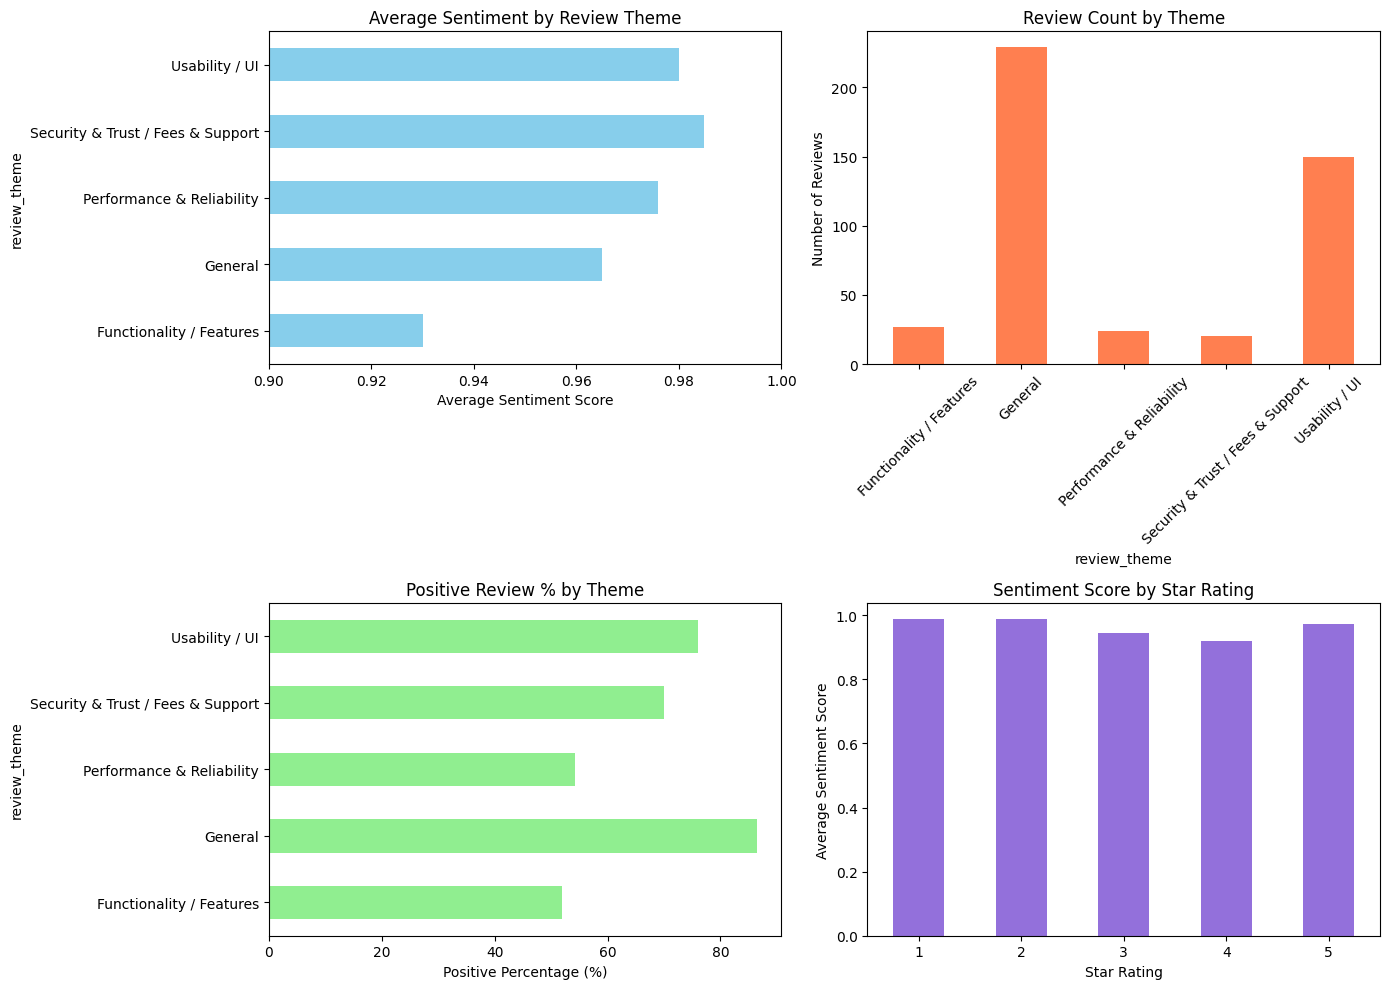


SENTIMENT & THEME ANALYSIS SUMMARY

Total Reviews Analyzed: 450
Overall Positive Percentage: 78.4%
Average Sentiment Score: 0.969

Theme Breakdown:
                                   avg_sentiment  review_count  \
review_theme                                                     
Functionality / Features                   0.930            27   
General                                    0.965           229   
Performance & Reliability                  0.976            24   
Security & Trust / Fees & Support          0.985            20   
Usability / UI                             0.980           150   

                                   positive_percentage  
review_theme                                            
Functionality / Features                        51.852  
General                                         86.463  
Performance & Reliability                       54.167  
Security & Trust / Fees & Support               70.000  
Usability / UI                                

In [19]:
import seaborn as sns

# 1. Create a comprehensive comparison visualization
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Sentiment by Theme
sentiment_by_theme['avg_sentiment'].plot(kind='barh', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_xlabel('Average Sentiment Score')
axes[0, 0].set_title('Average Sentiment by Review Theme')
axes[0, 0].set_xlim([0.9, 1.0])

# Plot 2: Review Count by Theme
sentiment_by_theme['review_count'].plot(kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_ylabel('Number of Reviews')
axes[0, 1].set_title('Review Count by Theme')
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3: Positive Percentage by Theme
sentiment_by_theme['positive_percentage'].plot(kind='barh', ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_xlabel('Positive Percentage (%)')
axes[1, 0].set_title('Positive Review % by Theme')

# Plot 4: Sentiment by Star Rating
sentiment_by_rating['avg_sentiment_score'].plot(kind='bar', ax=axes[1, 1], color='mediumpurple')
axes[1, 1].set_ylabel('Average Sentiment Score')
axes[1, 1].set_xlabel('Star Rating')
axes[1, 1].set_title('Sentiment Score by Star Rating')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# 2. Summary statistics
print("\n" + "="*60)
print("SENTIMENT & THEME ANALYSIS SUMMARY")
print("="*60)
print(f"\nTotal Reviews Analyzed: {len(df)}")
print(f"Overall Positive Percentage: {(df['sentiment_label'] == 'POSITIVE').sum() / len(df) * 100:.1f}%")
print(f"Average Sentiment Score: {df['sentiment_score'].mean():.3f}")
print(f"\nTheme Breakdown:")
print(sentiment_by_theme)

In [20]:
# Save results to CSV with specified columns
output_df = df[['review_id', 'review_text', 'sentiment_label', 'sentiment_score', 'review_theme']].copy()
output_df.rename(columns={'review_theme': 'identified_theme'}, inplace=True)

output_df.to_csv('cbe_sentiment_analysis_results.csv', index=False)

print("✅ Results saved to 'cbe_sentiment_analysis_results.csv'")
print(f"Total records exported: {len(output_df)}")
print("\nFirst few rows:")
print(output_df.head())

✅ Results saved to 'cbe_sentiment_analysis_results.csv'
Total records exported: 450

First few rows:
                              review_id  \
0  ff53332b-2e76-46d6-83d3-f93f968a4b18   
1  363a5616-ed3d-4274-85ee-77071067f81d   
2  56185597-d29b-4a60-a0fb-6783638230a7   
3  35efe702-40c9-4e46-ad67-7574ab9ef42d   
4  b41cb49d-59d3-41b8-bbb2-b1952005951b   

                                         review_text sentiment_label  \
0                                            is good        POSITIVE   
1                                                wow        POSITIVE   
2                                   Good application        POSITIVE   
3  Nice, but I can't get some recently transactio...        POSITIVE   
4  Very Secure but very poor interface and limite...        NEGATIVE   

   sentiment_score                   identified_theme  
0         0.999816                            General  
1         0.999592                            General  
2         0.999855                     